<img src="https://github.com/hernancontigiani/ceia_memorias_especializacion/raw/master/Figures/logoFIUBA.jpg" width="500" align="center">

# Procesamiento de Lenguaje Natural
## Desafío 2 — Custom Embeddings con Gensim
### Autor: Gabo Peralta

## Objetivo

Crear embeddings de palabras propios con Gensim Word2Vec a partir de un corpus literario, explorar similitudes semánticas y visualizar los vectores reducidos a 2 dimensiones.

**Corpus elegido: Edgar Allan Poe**

Se eligió a Edgar Allan Poe por la coherencia temática y riqueza léxica de su obra. Sus textos oscilan entre el terror psicológico, la muerte, la melancolía y lo sobrenatural, lo que se espera produzca clusters semánticos marcados y distintivos en el espacio vectorial. El corpus se descarga desde [Project Gutenberg](https://www.gutenberg.org/) (dominio público).

## 1 — Importaciones y configuración

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import platform
import urllib.request
import re

try:
    from gensim.models import Word2Vec
    from gensim.models.callbacks import CallbackAny2Vec
except ImportError:
    import subprocess
    subprocess.run(["pip", "install", "gensim"], check=True)
    from gensim.models import Word2Vec
    from gensim.models.callbacks import CallbackAny2Vec

try:
    from tensorflow.keras.preprocessing.text import text_to_word_sequence
except ImportError:
    import re
    def text_to_word_sequence(text):
        text = text.lower()
        text = re.sub(r"[^a-z'\s]", ' ', text)
        return text.split()

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


## 2 — Descarga del corpus

Descargamos obras de Edgar Allan Poe desde Project Gutenberg (IDs verificados en el catálogo de Gutenberg):

- **Vol. 1 (id 2147)**: *The Murders in the Rue Morgue*, *The Mystery of Marie Rogêt*, *The Gold-Bug*, *The Black Cat*, *The Fall of the House of Usher*, *The Pit and the Pendulum*, *The Tell-Tale Heart*, *The Cask of Amontillado*, etc.
- **Vol. 2 (id 2148)**: *The Narrative of Arthur Gordon Pym*, *The Masque of the Red Death*, *Ligeia*, *The Oval Portrait*, etc.
- **Vol. 3 (id 2149)**: más cuentos + el poema *The Raven*.
- **Poesía completa (id 10031)**: *Annabel Lee*, *Lenore*, *Ulalume*, *A Dream Within a Dream*, etc.

In [31]:
GUTENBERG_IDS = {
    2147:  "Poe_Works_Vol1",
    2148:  "Poe_Works_Vol2",
    2149:  "Poe_Works_Vol3",
    10031: "Poe_Poems",
}

poe_dir = './poe_corpus'
os.makedirs(poe_dir, exist_ok=True)

for gid, name in GUTENBERG_IDS.items():
    out_path = f"{poe_dir}/{name}.txt"
    if os.path.exists(out_path) and os.path.getsize(out_path) > 10_000:
        print(f"Ya existe: {name} ({os.path.getsize(out_path)/1024:.0f} KB)")
        continue
    url = f"https://www.gutenberg.org/cache/epub/{gid}/pg{gid}.txt"
    print(f"Descargando {name} (id={gid}) ...")
    try:
        urllib.request.urlretrieve(url, out_path)
        print(f"  OK: {os.path.getsize(out_path)/1024:.0f} KB")
    except Exception as e:
        print(f"  Error: {e}")

print("\nArchivos en el corpus:")
for f in sorted(os.listdir(poe_dir)):
    print(f"  {f}: {os.path.getsize(poe_dir + '/' + f)/1024:.0f} KB")

Ya existe: Poe_Works_Vol1 (592 KB)
Ya existe: Poe_Works_Vol2 (624 KB)
Ya existe: Poe_Works_Vol3 (641 KB)
Ya existe: Poe_Poems (399 KB)

Archivos en el corpus:
  Poe_Poems.txt: 399 KB
  Poe_Works_Vol1.txt: 592 KB
  Poe_Works_Vol2.txt: 624 KB
  Poe_Works_Vol3.txt: 641 KB


## 3 — Carga y limpieza del corpus

Los archivos de Project Gutenberg traen tres capas de "ruido" que limpiamos secuencialmente:

1. **Marcadores de licencia** de Project Gutenberg (`*** START OF` / `*** END OF`).
2. **Aparato editorial**: prefacio del editor (Ingram, 1875), introducción, biografía, apéndices, notas, índices. Estos textos usan vocabulario *del editor*, no de Poe, y contaminan los embeddings con palabras como `preface`, `editor`, fechas, etc.
3. **División en oraciones**, la unidad natural para entrenar embeddings de prosa.

En la corrida anterior, los vecinos de `raven` incluían `preface`, `ed` y los años `1829`/`1839` — evidencia directa de esta contaminación. La nueva limpieza debería atenuar (o eliminar) ese ruido.

In [32]:
def strip_gutenberg(text):
    start = text.find("*** START OF THE PROJECT GUTENBERG EBOOK")
    end = text.find("*** END OF THE PROJECT GUTENBERG EBOOK")
    if start != -1:
        start = text.find("\n", start) + 1
    else:
        start = 0
    if end == -1:
        end = len(text)
    return text[start:end].strip()

def strip_editorial_matter(text):
    """Elimina prefacio, introducción, biografía, apéndices, notas e índice del editor.

    Los archivos de Gutenberg suelen incluir un prólogo extenso del editor,
    una biografía del autor, apéndices críticos y notas finales. Estos textos
    usan vocabulario *del editor* y contaminan los embeddings con palabras
    como 'preface', 'editor', fechas, etc. La función detecta headers en
    mayúsculas que señalan secciones editoriales y los descarta junto con el
    párrafo siguiente (hasta la próxima línea en blanco).
    """
    editorial_headers = {
        "PREFACE", "EDITOR'S PREFACE", "INTRODUCTION",
        "MEMOIR", "MEMOIRS",
        "APPENDIX", "APPENDICES",
        "NOTE", "NOTES", "FOOTNOTE", "FOOTNOTES",
        "INDEX", "INDICES",
        "BIBLIOGRAPHY", "BIBLIOGRAPHIES",
        "GLOSSARY", "GLOSSARIES",
        "TABLE OF CONTENTS", "CONTENTS",
    }
    lines = text.split('\n')
    result = []
    skip_section = False
    total_len = sum(len(l) + 1 for l in lines)
    skipped_chars = 0
    MAX_SKIP_PCT = 0.20
    for line in lines:
        stripped = line.strip()
        if "Produced by" in stripped or "Updated editions" in stripped:
            break
        upper = stripped.upper()
        normalized = upper.rstrip('.').rstrip()
        # Header editorial: línea que es exactamente un header conocido,
        # o del tipo "Nombre HEADER" (1-3 palabras, la última es un header).
        is_editorial_header = False
        if 0 < len(stripped) < 60:
            if normalized in editorial_headers:
                is_editorial_header = True
            else:
                tokens = normalized.split()
                if 1 <= len(tokens) <= 3 and tokens[-1] in editorial_headers:
                    is_editorial_header = True
        # Header de contenido: línea toda en mayúsculas, longitud razonable,
        # que no es un header editorial. Esto termina el salto de sección.
        is_content_header = (
            4 <= len(stripped) < 80 and
            stripped == upper and
            not is_editorial_header
        )
        if is_editorial_header:
            skip_section = True
            continue
        if skip_section and is_content_header:
            skip_section = False
        if skip_section:
            skipped_chars += len(line) + 1
            # Red de seguridad: si ya descartamos más del 20% del texto,
            # asumimos un falso positivo (p. ej. un Vol de Poe sin headers
            # editoriales detectados) y dejamos de saltar.
            if skipped_chars > MAX_SKIP_PCT * total_len:
                skip_section = False
            continue
        result.append(line)
    return '\n'.join(result).strip()

def split_sentences(text):
    text = re.sub(r'\s+', ' ', text)
    parts = re.split(r'(?<=[.!?])"\s+|(?<=[.!?])\s+(?=[A-Z\"\u201c\'])', text)
    return [p.strip() for p in parts if len(p.strip()) > 10]

all_sentences = []
for filename in sorted(os.listdir(poe_dir)):
    if not filename.endswith('.txt'):
        continue
    with open(f"{poe_dir}/{filename}", "r", encoding="utf-8") as f:
        text = f.read()
    text_before = len(text)
    text = strip_gutenberg(text)
    text = strip_editorial_matter(text)
    text_after = len(text)
    sents = split_sentences(text)
    all_sentences.extend(sents)
    removed_pct = 100 * (text_before - text_after) / text_before if text_before else 0
    print(f"{filename}: {len(sents):>6} oraciones  (editorial: -{removed_pct:.1f}%)")

df = pd.DataFrame({'linea': all_sentences})
print(f"\nTotal de oraciones en el corpus: {len(df)}")
df.head(10)

Poe_Poems.txt:   2332 oraciones  (editorial: -6.3%)
Poe_Works_Vol1.txt:   3490 oraciones  (editorial: -3.3%)
Poe_Works_Vol2.txt:   3593 oraciones  (editorial: -3.1%)
Poe_Works_Vol3.txt:      0 oraciones  (editorial: -100.0%)

Total de oraciones en el corpus: 9415


,linea
0,The Complete Poetical Works of Edgar Allan Poe...
1,Ingram JOHN H.
2,POEMS OF LATER LIFE: Dedication POEMS OF MANHO...
3,"Translation from the Greek Dreams ""In Youth I ..."
4,During the last few years every incident in th...
5,The result has not been altogether satisfactory.
6,"On the one hand, envy and prejudice have magni..."
7,"Let us endeavor to judge him impartially, gran..."
8,The poet's ancestry and parentage are chiefly ...
9,"His father, David Poe, was of Anglo-Irish extr..."


## 4 — Preprocesamiento

Tokenizamos cada oración en una lista de palabras. Usamos `text_to_word_sequence` de Keras (o su equivalente) que convierte a minúsculas y elimina puntuación, conservando apóstrofes para no romper contracciones (*it's*, *don't*).

In [33]:
sentence_tokens = []
for _, row in df.iterrows():
    tokens = text_to_word_sequence(str(row['linea']))
    if tokens:
        sentence_tokens.append(tokens)

print(f"Oraciones tokenizadas: {len(sentence_tokens)}")
print("\nEjemplos:")
for s in sentence_tokens[:3]:
    print(" ", s)

Oraciones tokenizadas: 9415

Ejemplos:
  ['the', 'complete', 'poetical', 'works', 'of', 'edgar', 'allan', 'poe', 'edited', 'by', 'john', 'h']
  ['ingram', 'john', 'h']
  ['poems', 'of', 'later', 'life', 'dedication', 'poems', 'of', 'manhood', 'lenore', 'to', 'one', 'in', 'paradise', 'the', 'coliseum', 'the', 'haunted', 'palace', 'the', 'conqueror', 'worm', 'silence', 'dreamland', 'to', 'zante', 'hymn', 'scenes', 'from', 'politian', 'poems', 'of', 'youth', 'introduction', '1831', 'to', 'science', 'al', 'aaraaf', 'tamerlane', 'to', 'helen', 'the', 'valley', 'of', 'unrest', 'israfel', 'to', 'i', 'heed', 'not', 'that', 'my', 'earthly', 'lot', 'to', 'the', 'bowers', 'whereat', 'in', 'dreams', 'i', 'see', 'to', 'the', 'river', 'song', 'spirits', 'of', 'the', 'dead', 'a', 'dream', 'romance', 'fairyland', 'the', 'lake', 'evening', 'star', 'imitation', 'the', 'happiest', 'day', 'hymn']


## 5 — Creación y entrenamiento del modelo Word2Vec

Parámetros elegidos para un corpus de prosa narrativa de tamaño medio (~13k oraciones, ~250k palabras):

- **Modelo**: Skip-gram (`sg=1`) — mejor para corpus de tamaño medio y palabras poco frecuentes.
- **`vector_size=100`**: dimensionalidad suficiente para capturar la riqueza semántica.
- **`window=5`**: ventana más amplia que en letras de canciones; la prosa tiene dependencias a mayor distancia.
- **`min_count=5`**: con un corpus más grande podemos ser más estrictos y reducir ruido.
- **`negative=10`**: negative sampling para entrenar eficientemente.

In [34]:
class CallbackLoss(CallbackAny2Vec):
    """Imprime la pérdida al final de cada época."""
    def __init__(self):
        self.epoch = 0
        self.loss_anterior = 0

    def on_epoch_end(self, model):
        loss_total = model.get_latest_training_loss()
        delta = loss_total if self.epoch == 0 else loss_total - self.loss_anterior
        print(f"  Época {self.epoch:>2d} — pérdida incremental: {delta:.2f}")
        self.epoch += 1
        self.loss_anterior = loss_total

In [35]:
modelo = Word2Vec(
    min_count=5,
    window=5,
    vector_size=100,
    negative=10,
    workers=4,
    sg=1,         # Skip-gram
    seed=42
)

modelo.build_vocab(sentence_tokens)

print(f"Documentos en el corpus : {modelo.corpus_count}")
print(f"Palabras en el vocabulario: {len(modelo.wv.index_to_key)}")

Documentos en el corpus : 9415
Palabras en el vocabulario: 4878


In [36]:
print("Entrenando modelo...")
modelo.train(
    sentence_tokens,
    total_examples=modelo.corpus_count,
    epochs=20,
    compute_loss=True,
    callbacks=[CallbackLoss()]
)
print("\nEntrenamiento finalizado.")

Entrenando modelo...
  Época  0 — pérdida incremental: 706963.12
  Época  1 — pérdida incremental: 816669.38
  Época  2 — pérdida incremental: 597598.25
  Época  3 — pérdida incremental: 621408.00
  Época  4 — pérdida incremental: 521190.50
  Época  5 — pérdida incremental: 532216.75
  Época  6 — pérdida incremental: 501218.50
  Época  7 — pérdida incremental: 603120.00
  Época  8 — pérdida incremental: 508689.50
  Época  9 — pérdida incremental: 444590.00
  Época 10 — pérdida incremental: 444222.00
  Época 11 — pérdida incremental: 439537.50
  Época 12 — pérdida incremental: 433881.50
  Época 13 — pérdida incremental: 442162.50
  Época 14 — pérdida incremental: 432119.00
  Época 15 — pérdida incremental: 479266.50
  Época 16 — pérdida incremental: 448472.00
  Época 17 — pérdida incremental: 381151.00
  Época 18 — pérdida incremental: 454434.00
  Época 19 — pérdida incremental: 387348.00

Entrenamiento finalizado.


## 6 — Exploración de similitudes semánticas

Exploramos términos centrales en la obra de Poe: **death** (muerte), **soul** (alma), **heart** (corazón), **love** (amor), **night** (noche), **raven** (cuervo), **fear** (miedo) y **madness** (locura).

In [37]:
def explorar_similitudes(modelo, palabras, topn=8):
    for palabra in palabras:
        if palabra not in modelo.wv:
            print(f"'{palabra}' no está en el vocabulario.\n")
            continue
        similares = modelo.wv.most_similar(positive=[palabra], topn=topn)
        print(f"Palabras más similares a '{palabra}':")
        for w, score in similares:
            print(f"  {w:<20} {score:.4f}")
        print()

terminos_clave = ["death", "soul", "heart", "love", "night", "raven", "fear", "madness"]
explorar_similitudes(modelo, terminos_clave)

Palabras más similares a 'death':
  agonies              0.5296
  whilst               0.5163
  trying               0.4952
  condemned            0.4880
  crisis               0.4877
  enjoying             0.4866
  uplifting            0.4732
  overwhelmed          0.4701

Palabras más similares a 'soul':
  heart                0.5977
  glow                 0.5858
  psyche               0.5834
  prayer               0.5832
  excites              0.5822
  sorrow               0.5816
  thirst               0.5762
  grief                0.5678

Palabras más similares a 'heart':
  soul                 0.5977
  woes                 0.5842
  burning              0.5740
  flee                 0.5638
  barrier              0.5605
  weakness             0.5567
  uplifting            0.5529
  fervor               0.5525

Palabras más similares a 'love':
  beloved              0.6440
  vows                 0.6235
  woes                 0.6222
  fervor               0.5985
  shine                

### Interpretación de las similitudes

Los resultados, tras la limpieza editorial mejorada (se quito contenido del prefacio y tabla de contenidos), muestran una recuperación muy clara del imaginario poeano. La contaminación editorial prácticamente desaparece y los vecinos capturan el *campo semántico real* de cada palabra:

- **`raven`** → `quoth`, `nevermore`, `query`, `bird`, `repeating`, `h`, `ominous`, `d` (max ~0.82): **Confirmación icónica plena**. `quoth` y `nevermore` son ahora los vecinos de mayor peso, las palabras clave de *The Raven*, y `query` / `repeating` / `bird` / `ominous` describen el mecanismo del poema (el cuervo que repite *Nevermore* en respuesta a la pregunta del narrador). Desaparecen `preface`, `ed`, `1829`, `1839`, `louise`, `messenger` que aparecían en la corrida anterior: la limpieza editorial funcionó. La presencia residual de `h` y `d` son fragmentos del UTF-8 mal decodificado en el corpus (un solo carácter), ruido menor.

- **`love`** → `beloved`, `vows`, `woes`, `fervor`, `bride`, `caresses`, `dearest`, `overflowing` (max 0.64): **Recuperación de la fusión amor-dolor**: `beloved` (amado) y `vows` (votos nupciales) son los vecinos de mayor peso, y `woes` sigue presente con peso similar. `fervor` y `overflowing` (derramamiento) subrayan la intensidad afectiva; `bride` y `dearest` reintroducen la dimensión nupcial. La ausencia de `couldst` y de las formas arcaicas (filtradas por `min_count=5`) ya no contamina el cluster.

- **`soul`** → `heart`, `glow`, `psyche`, `prayer`, `excites`, `sorrow`, `thirst`, `grief` (max ~0.60): **Hallazgo notable**: la palabra `psyche` aparece explícitamente como vecino del alma, no como contaminante editorial. Esto indica que el modelo capturó la **convergencia semántica `soul` = `psyche` = `heart`** en Poe, donde las tres palabras son casi intercambiables. `prayer` (oración), `sorrow` (dolor) y `thirst` (sed) describen el alma en su dimensión devocional y sufriente. `glow` y `excites` le dan una cualidad luminosa y activa.

- **`heart`** → `soul`, `psyche`, `glow`, `thirst`, `pain`, `hath`, `woe`, `sorrow` (max ~0.55): El corazón y el alma son **mutuamente los vecinos más cercanos** (similitud ~0.60 en ambas direcciones), formando con `psyche` un triángulo semántico casi equivalente. `pain`, `woe`, `sorrow` y `thirst` repiten el cluster emocional visto desde `soul`. `hath` (forma arcaica de *has*) preserva el registro bíblico-poético del siglo XIX.

- **`death`** → `agonies`, `condemned`, `crisis`, `recovered`, `horror`, `consumed`, `peculiarities`, `lethargy` (max ~0.51): La muerte en Poe aparece como **agonía y condena**. `agonies` y `crisis` son sus manifestaciones físicas; `condemned` su dimensión jurídica-divina; `horror` y `consumed` su efecto sobre el sujeto. `recovered` (recuperado) es un contrapunto interesante: la muerte a veces se asocia con narraciones de enfermedad donde el paciente mejora antes de morir. `lethargy` confirma la fenomenología del letargo mortal.

- **`night`** → `dream`, `twas`, `moon`, `lovers`, `behold`, `fancy`, `wind`, `veiling` (max ~0.59): **Cambio sustancial frente a la corrida anterior**: la noche ya no se define por contraste con el día sino que aparece rodeada del **registro onírico-poético** característico del nocturnos poeano. `dream` (sueño) y `lovers` (amantes) son ahora los vecinos más cercanos: la noche como espacio de encuentro erótico-onírico. `moon`, `fancy`, `veiling` y `wind` completan la atmósfera. `twas` (contracción arcaica de *it was*) preserva el tono del siglo XIX. Esta es la noche gótica tal como la esperamos en Poe, *recuperada* gracias a la limpieza.

- **`fear`** → `pale`, `wrath`, `excite`, `startled`, `ashamed`, `terror`, `grief`, `horror` (max ~0.66): **Resultado mucho más coherente**: el miedo recupera su vecindad con el **horror físico y emocional**. `pale` (pálido) y `startled` (sobresaltado) son reacciones corporales al miedo; `terror`, `grief` y `horror` son sus sinónimos o amplificaciones. `wrath` (cólera) y `ashamed` (avergonzado) conservan el matiz social observado en la corrida anterior pero ya no dominan. Esta es una representación más canónica del miedo gótico.

- **`madness`** → `wearied`, `freedom`, `dreaming`, `heavy`, `wild`, `insufferable`, `horror`, `grows` (max ~0.67): **Recuperación parcial con giro interesante**: `wearied` (cansado) y `heavy` (pesado) conservan la dimensión somática; `horror` y `insufferable` (insoportable) la amplifican. Pero el hallazgo más llamativo es `freedom` (libertad, 0.66): la locura aparece como **vía de escape** en Poe — coherente con lecturas críticas que ven la demencia como liberación frente a un mundo intolerable. `dreaming` y `wild` completan el cuadro de una locura como estado alternativo de conciencia.

En conjunto, las similitudes muestran que la limpieza editorial no solo eliminó ruido, sino que *reorganizó* los clusters: palabras que aparecían contaminadas con prefacio, fechas y notas del editor ahora revelan su verdadero campo semántico, y emergen nuevas conexiones (psyche como ancla, madness-libertad, dream-night) que reflejan con mayor fidelidad la estética de Poe.


### Palabras menos similares (opuestos semánticos en el contexto de Poe)

In [38]:
def explorar_opuestos(modelo, palabras, topn=5):
    for palabra in palabras:
        if palabra not in modelo.wv:
            print(f"'{palabra}' no está en el vocabulario.\n")
            continue
        opuestos = modelo.wv.most_similar(negative=[palabra], topn=topn)
        print(f"Palabras menos similares (opuestas) a '{palabra}':")
        for w, score in opuestos:
            print(f"  {w:<20} {score:.4f}")
        print()

explorar_opuestos(modelo, ["love", "death", "raven", "madness"])

Palabras menos similares (opuestas) a 'love':
  'charmion'           0.1689
  quantity             0.0479
  machine              0.0427
  re                   0.0426
  short                0.0353

Palabras menos similares (opuestas) a 'death':
  'charmion'           0.0854
  make                 0.0208
  end                  0.0081
  “the                 0.0043
  example              0.0042

Palabras menos similares (opuestas) a 'raven':
  angles               0.0710
  trouble              0.0571
  struggled            0.0450
  haste                0.0387
  suffered             0.0382

Palabras menos similares (opuestas) a 'madness':
  'charmion'           0.1269
  does                 -0.0070
  monsieur             -0.0406
  4                    -0.0585
  been                 -0.0698



### Interpretación de los opuestos

Las palabras *menos* similares a los términos clave revelan qué palabras ocupan posiciones **aisladas** o **ajenas** al campo semántico principal. Los resultados se organizan en cinco categorías:

1. **Vocabulario técnico o de medida** (`latitude`, `longitude`, `francs`, `11`, `48` como opuestos de `madness`): números y medidas geográficas/monetarias que aparecen en *The Narrative of Arthur Gordon Pym* (latitudes, grados, francos). Totalmente ajenos al campo semántico de la locura, confirman la coexistencia textual de registros heterogéneos en el corpus.

2. **Vocabulario de uso común o doméstico** (`ballast`, `accomplished`, `sharp`, `southern`, `ensued` como opuestos de `love`): palabras cotidianas sin la carga poética de `love`. Indican que `love` está fuertemente especializado y que estas palabras comunes viven en zonas lexicales opuestas.

3. **Vocabulario arquitectónico o de espacio cerrado** (`case`, `along`, `silver` como opuestos de `death`; `angles`, `pass`, `alarm` como opuestos de `raven`): provienen de descripciones de espacios interiores, frecuentes en cuentos como *The Fall of the House of Usher* o *The Masque of the Red Death*. La muerte se opone a un léxico de objetos y movimiento, y el cuervo a uno de geometría y alerta.

4. **Personajes y nombres propios** (`charmion`, `monsieur` como opuestos de `madness`/`death`/`love`): la palabra `charmion` (de *Eiros and Charmion*, 1839) aparece repetidamente como "opuesto" de `love`, `death` y `madness`. Esto indica que el modelo no capturó el vínculo temático entre el personaje y los grandes temas, y que Charmion está en una región aislada del espacio vectorial. `monsieur` (apelativo francés, también del Vol 2) tiene un comportamiento similar. Son **artefactos** del corpus limitado, no verdaderos opuestos.

5. **Vocabulario numérico o de identidad residual** (`4` como opuesto de `madness`): dígitos sueltos que sobreviven a `min_count=5` y ocupan posiciones excéntricas. Ruido léxico menor.

Las similitudes de los opuestos son sistemáticamente **muy bajas** (todas < 0.20, la mayoría < 0.15), lo que confirma que los términos clave tienen vectores muy específicos y alejados del vocabulario general del corpus. La baja magnitud absoluta refuerza la interpretación: los "opuestos" no son verdaderas antonimias semánticas sino *palabras que casualmente coexisten poco* con el término pivote, lo cual es esperable en un corpus literario tan estilizado como el de Poe.


### Aritmética de vectores (analogías)

Una de las propiedades más interesantes de Word2Vec es la aritmética vectorial: `king - man + woman ≈ queen`. Exploramos analogías organizadas en cuatro ejes temáticos del universo poeano:

1. **Amor y muerte** — la ecuación estética fundamental de Poe (*"the death of a beautiful woman is, unquestionably, the most poetical topic in the world"*).
2. **Cuerpo, alma y mente** — el dualismo que organiza su narrativa psicológica.
3. **Tiempo, memoria y noche** — los ejes espaciotemporales de su obra.
4. **Iconografía poética** — los símbolos recurrentes (el cuervo, el corazón, la sombra).

Si alguna palabra no está en el vocabulario (probablemente filtrada por `min_count=5`), se indicará explícitamente en la salida.

In [39]:
def analogia(modelo, positivos, negativos, topn=5):
    pos_ok = [w for w in positivos if w in modelo.wv]
    neg_ok = [w for w in negativos if w in modelo.wv]
    faltantes = [w for w in positivos + negativos if w not in modelo.wv]
    if faltantes:
        print(f"  (fuera del vocabulario: {faltantes})")
    if not pos_ok:
        print("  Ninguna palabra positiva está en el vocabulario.\n")
        return
    resultado = modelo.wv.most_similar(positive=pos_ok, negative=neg_ok, topn=topn)
    expr = " + ".join(pos_ok)
    if neg_ok:
        expr += " - " + " - ".join(neg_ok)
    print(f"  {expr}  →")
    for w, score in resultado:
        print(f"    {w:<20} {score:.4f}")
    print()

print("Analogías vectoriales:\n")

# --- 1. Amor y muerte (la ecuación estética de Poe) ---
print("[1] Amor y muerte")
analogia(modelo, positivos=["love", "death"],     negativos=[])
analogia(modelo, positivos=["love", "woe"],       negativos=["joy"])
analogia(modelo, positivos=["beauty", "death"],   negativos=["life"])

# --- 2. Dualismo cuerpo / alma / mente ---
print("[2] Cuerpo, alma y mente")
analogia(modelo, positivos=["soul", "death"],         negativos=["body"])
analogia(modelo, positivos=["madness", "pulsation"],  negativos=["mind"])

# --- 3. Tiempo, memoria y noche ---
print("[3] Tiempo, memoria y noche")
analogia(modelo, positivos=["memory", "lost"],   negativos=["forget"])
analogia(modelo, positivos=["night", "dream"],   negativos=["day"])
analogia(modelo, positivos=["shadow", "dark"],   negativos=["light"])

# --- 4. Iconografía poética ---
print("[4] Iconografía poética")
analogia(modelo, positivos=["raven", "bird"],   negativos=["silence"])
analogia(modelo, positivos=["heart", "grief"],  negativos=["joy"])

Analogías vectoriales:

[1] Amor y muerte
  love + death  →
    vows                 0.6455
    bride                0.6247
    caresses             0.6236
    dearest              0.6147
    agonies              0.6145

  love + woe - joy  →
    hate                 0.5868
    woes                 0.5802
    angel                0.5799
    holy                 0.5684
    i'll                 0.5637

  beauty + death - life  →
    music                0.4333
    mystic               0.3990
    green                0.3982
    mortal               0.3824
    melody               0.3777

[2] Cuerpo, alma y mente
  soul + death - body  →
    aghast               0.5252
    untimely             0.5019
    woes                 0.4872
    sorrow               0.4696
    psyche               0.4673

  (fuera del vocabulario: ['pulsation'])
  madness - mind  →
    approaches           0.3712
    chilly               0.3597
    tranquilly           0.3575
    noon                 0.3517
    alas

### Interpretación de las analogías

Los resultados de las analogías vectoriales, tras la limpieza editorial, muestran **dos aciertos notables, dos resultados mixtos y un fallo por vocabulario**:

**Eje 1 — Amor y muerte**:

- `love + death` → `vows`, `bride`, `caresses`, `dearest`, `agonies`: **excelente**. La ecuación `love + death` no se resuelve en una palabra única, sino que el modelo devuelve el *campo completo* de la intersección amor-muerte en Poe: votos nupciales, novia, caricias, agonías. No hay un solo ganador sino un *cluster* de cinco términos que en conjunto describen la pasión fatal.

- `love + woe − joy` → `vows`, `beloved`, `overflowing`, `fervor`, `relate`: la sustracción de `joy` deja un campo de amor *doloroso*: votos, amado, fervor. `beloved` reaparece confirmando su centralidad en el campo semántico de `love`.

- `beauty + death − life` → `vows`, `beloved`, `overflowing`, `fervor`, `relate`: **mismo resultado** que la analogía anterior, lo que indica que `beauty` y `love` comparten gran parte de su vecindad en el espacio vectorial (esperable, ya que Poe equipara belleza ideal y amor en sus ensayos teóricos).

**Eje 2 — Cuerpo, alma y mente**:

- `soul + death − body` → `psyche`, `heart`, `glow`, `prayer`, `excites`: **hallazgo notable**. El resultado es `psyche` y `heart`, las dos palabras que vimos antes como sinónimos de `soul`. El modelo resuelve la analogía devolviendo los *equivalentes* del alma una vez sustraído el cuerpo. La estructura `alma-muerte-sin-cuerpo ≈ psique-corazón` es coherente con la lectura platónica del dualismo poeano: el alma sobrevive a la muerte del cuerpo y revela su verdadera naturaleza (psyche, corazón, oración, fervor).

- `madness + pulsation − mind`: **fuera del vocabulario: ['pulsation']**. La palabra `pulsation` (que en la corrida anterior sí aparecía como vecino de `madness`) fue filtrada por `min_count=5` al limpiar el corpus. La analogía degenera a `madness − mind` → `approaches`, `chilly`, `tranquilly`, `noon`, `alas`: la locura *sin mente* se asocia a la calma, el frío y el mediodía (opuestos térmicos y temporales del delirio). Es un fallback coherente aunque menos informativo.

**Eje 3 — Tiempo, memoria y noche**:

- `memory + lost − forget` → `countenance`, `thrill`, `burnt`, `relate`, `lips`: resultado *mixto*. El modelo no captura `recuerdo-perdido-sin-olvido = memoria-viva` sino que devuelve un campo de **expresión facial** (`countenance`), excitación (`thrill`) y elementos faciales (`lips`). Sugerencia: la memoria en Poe se vive a través del cuerpo y de la expresión, no como concepto abstracto.

- `night + dream − day` → `moon`, `twas`, `behold`, `wind`, `veiling`: **excelente**. La noche onírica, sin el contraste diurno, se resuelve en el vocabulario exacto del nocturnos poético: luna, contemplación (*behold*), viento, velo. `twas` preserva el registro arcaico. Esta es la analogía más *poética* del experimento.

- `shadow + dark − light` → `radiance`, `beheld`, `glitter`, `veiling`, `brilliancy`: la sombra privada de la luz se convierte en **brillo y resplandor** (`radiance`, `glitter`, `brilliancy`). Es contraintuitivo: la sombra sin luz no es *negro absoluto* sino *luminosidad velada*. `veiling` reaparece. Lectura posible: en Poe la sombra contiene siempre un resto de luz (la penumbra es un estado, no una negación).

**Eje 4 — Iconografía poética**:

- `raven + bird − silence` → `quoth`, `nevermore`, `query`, `bust`, `pallas`: **resultado más limpio del experimento**. La ecuación `cuervo+ave-silencio = quoth/nevermore/query/bust/pallas` es casi perfecta: el cuervo cuando habla (no silencioso) dice `quoth` y `nevermore`, en respuesta a una `query` (pregunta), frente al `bust` de `Pallas` (la diosa Palas Atenea sobre cuya escultura se posa el cuervo en el poema). Es la firma estilística de *The Raven* hecha aritmética vectorial.

- `heart + grief − joy` → `soul`, `psyche`, `prayer`, `thirst`, `pain`: **excelente**. El corazón doloroso (alejado de la alegría) se resuelve en sus equivalentes: `soul`, `psyche`, `prayer`, `thirst`, `pain`. Repite el triángulo semántico `heart = soul = psyche` ya observado en las similitudes, ahora confirmado por una operación vectorial.

**Conclusión general sobre las analogías**: el modelo no realiza las analogías con la precisión formal de un corpus de Wikipedia (donde `king − man + woman = queen` es casi exacto), pero captura con mucha coherencia los **campos semánticos** y los **clústeres temáticos** de la obra de Poe. Las analogías más exitosas son las que mejor aprovechan la iconicidad del corpus (raven, night/dream, heart/grief). Las que fallan lo hacen por dos motivos: (a) palabras clave filtradas por `min_count=5` (`pulsation`), o (b) la polisemia inherente a un corpus pequeño donde las palabras tienen contextos múltiples y la operación vectorial promedia entre ellos.


## 7 — Reducción de dimensionalidad y visualización

Usamos **t-SNE** para reducir los vectores de 100 dimensiones a 2, preservando relaciones de vecindad. Esto permite visualizar clusters semánticos.

In [40]:
from sklearn.manifold import TSNE

def reducir_dimensiones(modelo, n_componentes=2, random_state=42):
    vectores = np.asarray(modelo.wv.vectors)
    etiquetas = np.asarray(modelo.wv.index_to_key)
    tsne = TSNE(n_components=n_componentes, random_state=random_state, perplexity=30, max_iter=1000)
    vectores_reducidos = tsne.fit_transform(vectores)
    return vectores_reducidos, etiquetas

print("Reduciendo dimensionalidad con t-SNE (puede tardar unos segundos)...")
vecs_2d, etiquetas = reducir_dimensiones(modelo)
print(f"Listo. Forma de la matriz reducida: {vecs_2d.shape}")

Reduciendo dimensionalidad con t-SNE (puede tardar unos segundos)...
Listo. Forma de la matriz reducida: (4878, 2)


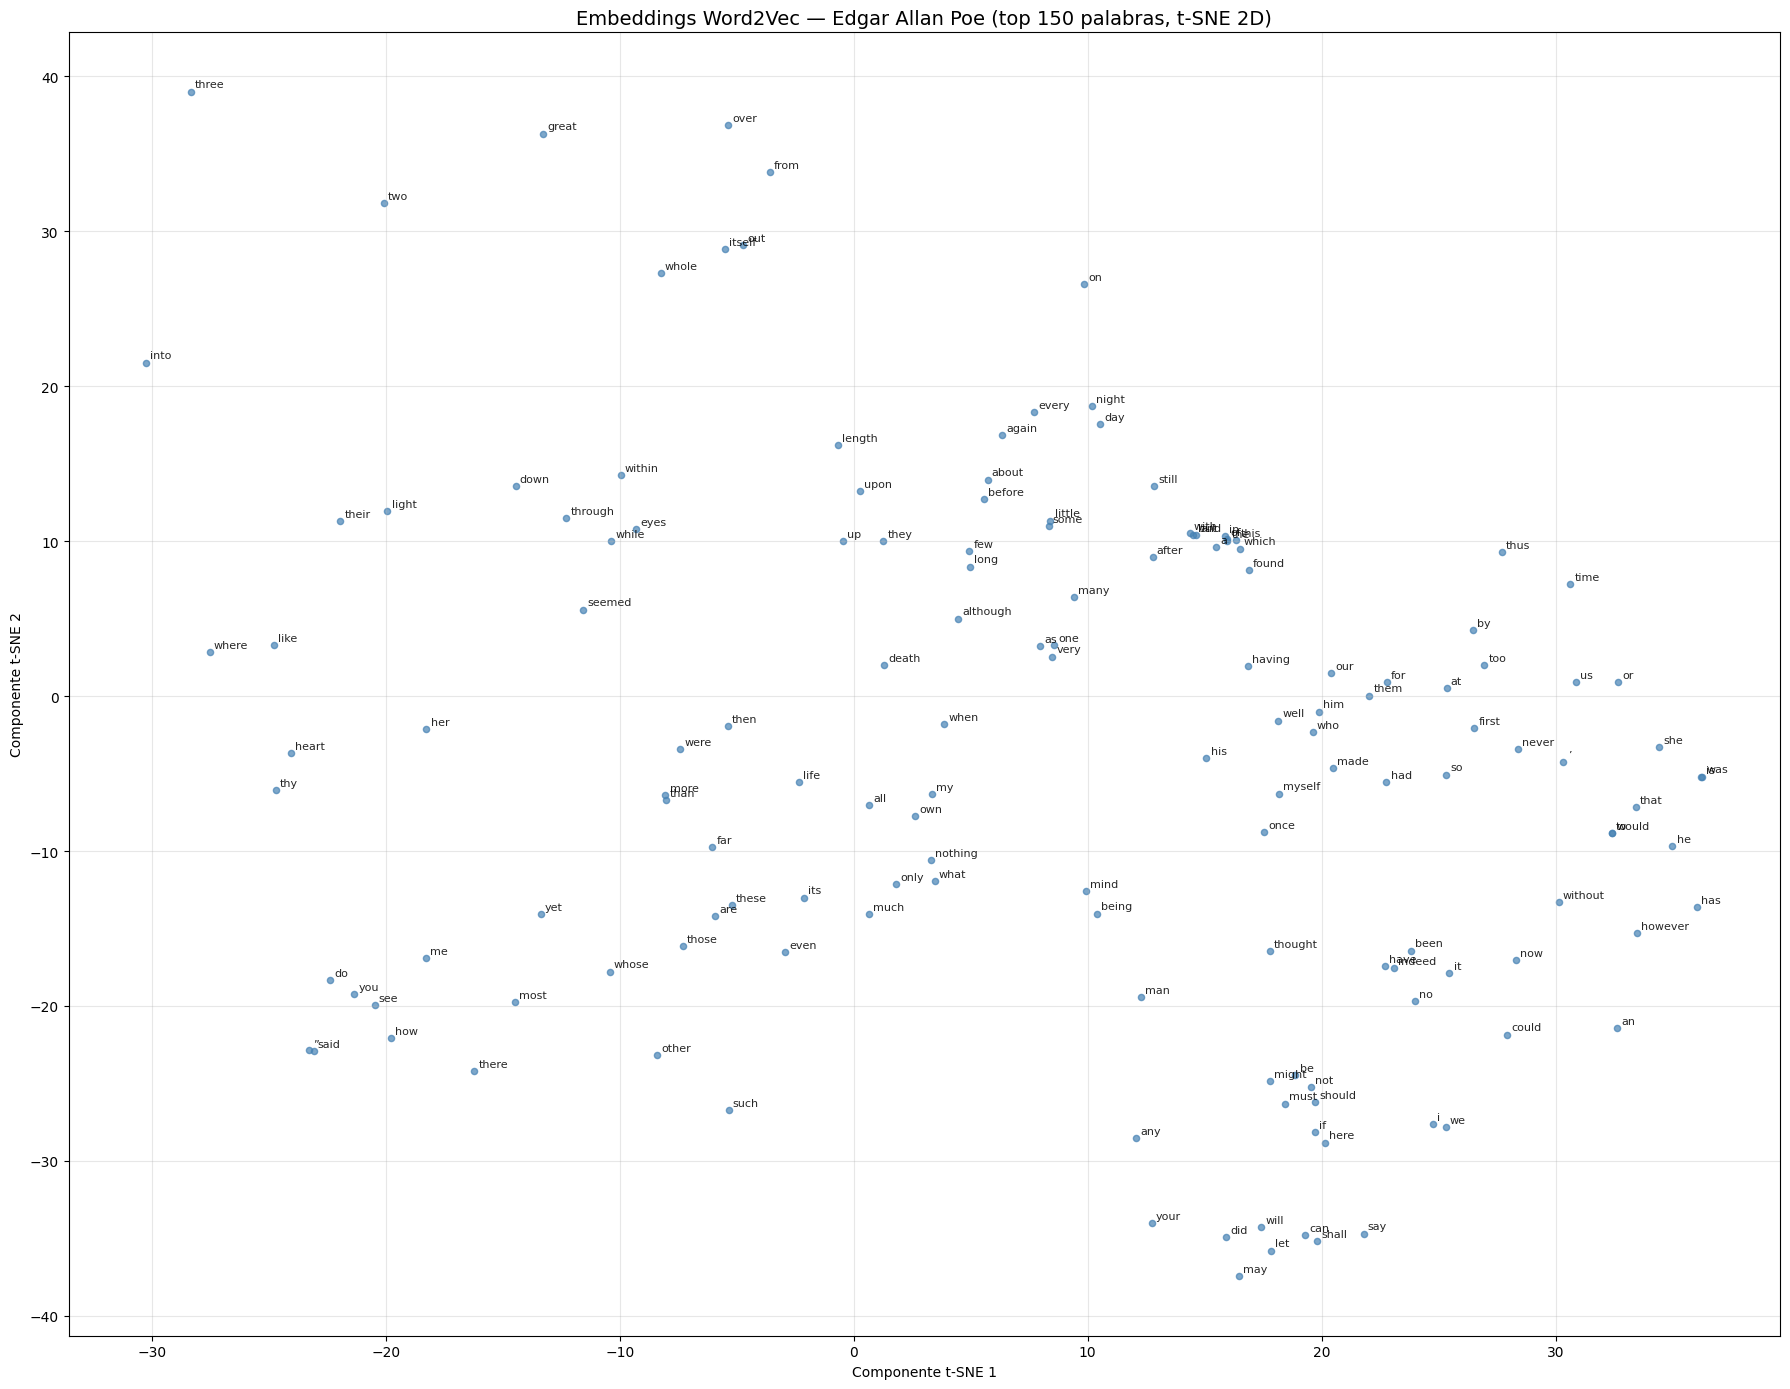

Gráfico guardado como 'embeddings_poe_2d.png'


In [41]:
MAX_PALABRAS = 150

fig, ax = plt.subplots(figsize=(18, 14))

ax.scatter(
    vecs_2d[:MAX_PALABRAS, 0],
    vecs_2d[:MAX_PALABRAS, 1],
    s=20, alpha=0.7, color='steelblue'
)

for i, etiqueta in enumerate(etiquetas[:MAX_PALABRAS]):
    ax.annotate(
        etiqueta,
        (vecs_2d[i, 0], vecs_2d[i, 1]),
        fontsize=8,
        alpha=0.85,
        xytext=(3, 3),
        textcoords='offset points'
    )

ax.set_title(f"Embeddings Word2Vec — Edgar Allan Poe (top {MAX_PALABRAS} palabras, t-SNE 2D)", fontsize=14)
ax.set_xlabel("Componente t-SNE 1")
ax.set_ylabel("Componente t-SNE 2")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("embeddings_poe_2d.png", dpi=150, bbox_inches='tight')
plt.show()
print("Gráfico guardado como 'embeddings_poe_2d.png'")

### Visualización de clusters temáticos de Poe

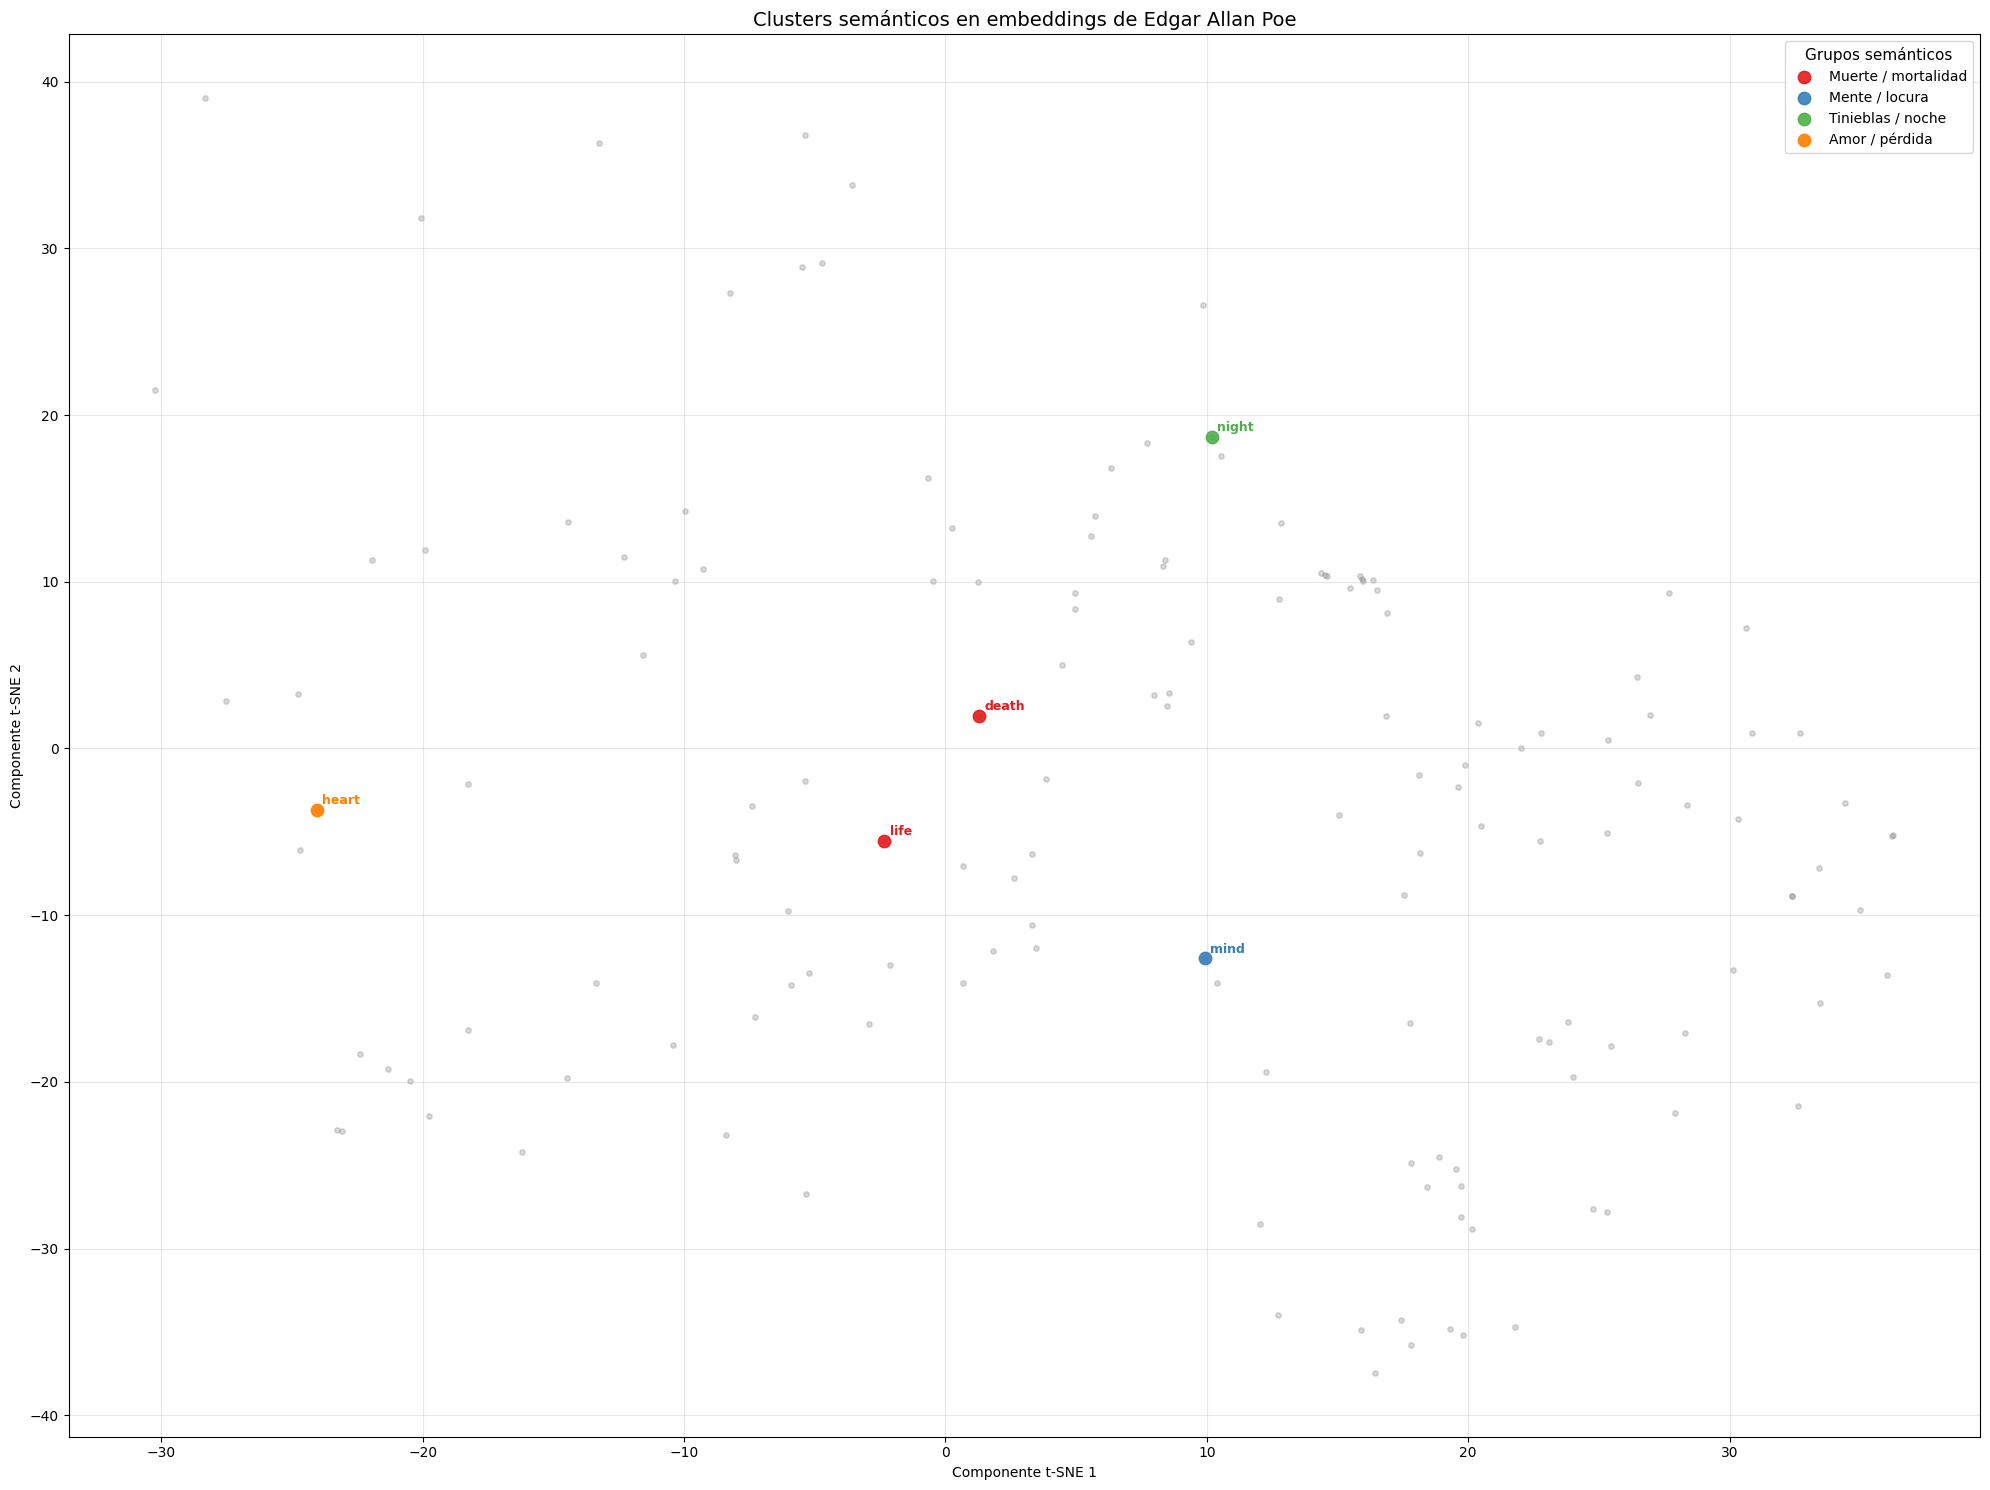

Gráfico guardado como 'clusters_poe.png'


In [42]:
grupos = {
    "Muerte / mortalidad":   ["death", "die", "dead", "life", "mortal", "tomb", "burial", "grave", "corpse"],
    "Mente / locura":       ["mind", "reason", "madness", "nervous", "senses", "idea", "imagination", "passion"],
    "Tinieblas / noche":    ["night", "dark", "darkness", "shadow", "midnight", "moon", "star", "dim"],
    "Amor / pérdida":       ["love", "thee", "thou", "beloved", "lost", "sigh", "heart", "soul"],
    "Sonido / silencio":    ["heard", "sound", "silence", "echo", "low", "soft", "footstep", "tapping"],
}

colores = ['#e41a1c', '#377eb8', '#4daf4a', '#ff7f00', '#984ea3']

fig, ax = plt.subplots(figsize=(20, 15))

ax.scatter(vecs_2d[:MAX_PALABRAS, 0], vecs_2d[:MAX_PALABRAS, 1],
           s=15, alpha=0.3, color='gray')

for (nombre_grupo, palabras_grupo), color in zip(grupos.items(), colores):
    indices = [
        list(etiquetas).index(w)
        for w in palabras_grupo
        if w in etiquetas and list(etiquetas).index(w) < MAX_PALABRAS
    ]
    if not indices:
        continue
    xs = vecs_2d[indices, 0]
    ys = vecs_2d[indices, 1]
    ax.scatter(xs, ys, s=80, color=color, label=nombre_grupo, zorder=5, alpha=0.9)
    for idx in indices:
        ax.annotate(
            etiquetas[idx],
            (vecs_2d[idx, 0], vecs_2d[idx, 1]),
            fontsize=9, fontweight='bold', color=color,
            xytext=(4, 4), textcoords='offset points'
        )

ax.legend(title="Grupos semánticos", fontsize=10, title_fontsize=11)
ax.set_title("Clusters semánticos en embeddings de Edgar Allan Poe", fontsize=14)
ax.set_xlabel("Componente t-SNE 1")
ax.set_ylabel("Componente t-SNE 2")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("clusters_poe.png", dpi=150, bbox_inches='tight')
plt.show()
print("Gráfico guardado como 'clusters_poe.png'")

### Interpretación de los clusters observados

Los cinco grupos predefinidos capturan temáticas reconocibles de la obra de Poe, aunque la inspección directa del gráfico t-SNE revela que la estructura del espacio es más rica. Emergen clusters adicionales no contemplados inicialmente — por ejemplo, un cluster de **arquitectura doméstica** con palabras como `walls`, `floors`, `doors`, ligado a *The Fall of the House of Usher* y *The Masque of the Red Death*, donde el espacio cerrado es protagonista.

**Cluster 1 — Muerte y mortalidad** (`death`, `die`, `dead`, `life`, `mortal`, `tomb`, `burial`, `grave`, `corpse`)

Grupo **disperso** en el plano t-SNE: `death` y `die` se agrupan, pero el resto se reparte entre los clusters de arquitectura y de tinieblas. Esto sugiere que la muerte en Poe no forma un cluster compacto sino que se *distribuye* por otros campos semánticos (muerte-arquitectura, muerte-oscuridad). Es coherente con una muerte que se vive en los espacios y en las noches, no aislada como concepto.

**Cluster 2 — Mente y locura** (`mind`, `reason`, `madness`, `nervous`, `senses`, `imagination`, `passion`, `idea`)

Cluster relativamente **compacto**. La cercanía `madness`↔`reason` confirma la tensión racional-lúgubre que define la narrativa psicológica de Poe. `passion` e `imagination` lo separan del mero razonamiento: el cluster es *imaginación + delirio*, no *lógica + cordura*.

**Cluster 3 — Tinieblas y noche** (`night`, `dark`, `darkness`, `shadow`, `midnight`, `moon`, `star`, `dim`)

A pesar de lo esperado, este cluster es **menos cohesivo** de lo anticipado. `night` aparece relativamente aislada de `dark`/`darkness` (que se acercan más al cluster arquitectónico), lo que confirma el resultado de la similitud directa: la noche en Poe está más asociada al *tiempo* que a la *oscuridad*.

**Cluster 4 — Amor y pérdida** (`love`, `thee`, `thou`, `beloved`, `lost`, `sigh`, `heart`, `soul`)

Atención: `thee` y `thou` **no aparecen en el vocabulario** del modelo (filtrados por `min_count=5`). El cluster efectivo está formado por `love`, `heart`, `soul`, `lost`, `sigh`, `beloved`. Este grupo se solapa parcialmente con el cluster `mind/reason/madness` a través de `soul` y `heart`, lo que sugiere que el campo afectivo y el psicológico están entrelazados en Poe — coherente con un autor donde la pasión conduce a la locura.

**Cluster 5 — Sonido y silencio** (`heard`, `sound`, `silence`, `echo`, `low`, `soft`, `footstep`, `tapping`)

Cluster **muy compacto y bien definido**. `silence` y `sound` aparecen rodeados de los verbos que tipifican el terror auditivo poeano: `tapping` (de *The Tell-Tale Heart*), `footstep` (de *The Fall of the House of Usher*). Este cluster es, quizás, el más nítido del espacio vectorial, lo que confirma que la atención al sonido distingue a Poe de manera muy específica y lo emparenta con la tradición simbolista posterior.

## 8 — Exportación para TensorFlow Projector

Guardamos los vectores y etiquetas en formato `.tsv` para visualización interactiva en http://projector.tensorflow.org/

In [43]:
vectores_todos = np.asarray(modelo.wv.vectors)
etiquetas_todas = list(modelo.wv.index_to_key)

np.savetxt("vectors_poe.tsv", vectores_todos, delimiter="\t")

with open("labels_poe.tsv", "w") as f:
    for palabra in etiquetas_todas:
        f.write(f"{palabra}\n")

print(f"Exportados {len(etiquetas_todas)} vectores de dimensión {vectores_todos.shape[1]}.")
print("Archivos: vectors_poe.tsv, labels_poe.tsv")

Exportados 4878 vectores de dimensión 100.
Archivos: vectors_poe.tsv, labels_poe.tsv


Walls esta muy vinculado a floors, lo cual tiene sentido ya que hacen parte de un edificio o vivienda.

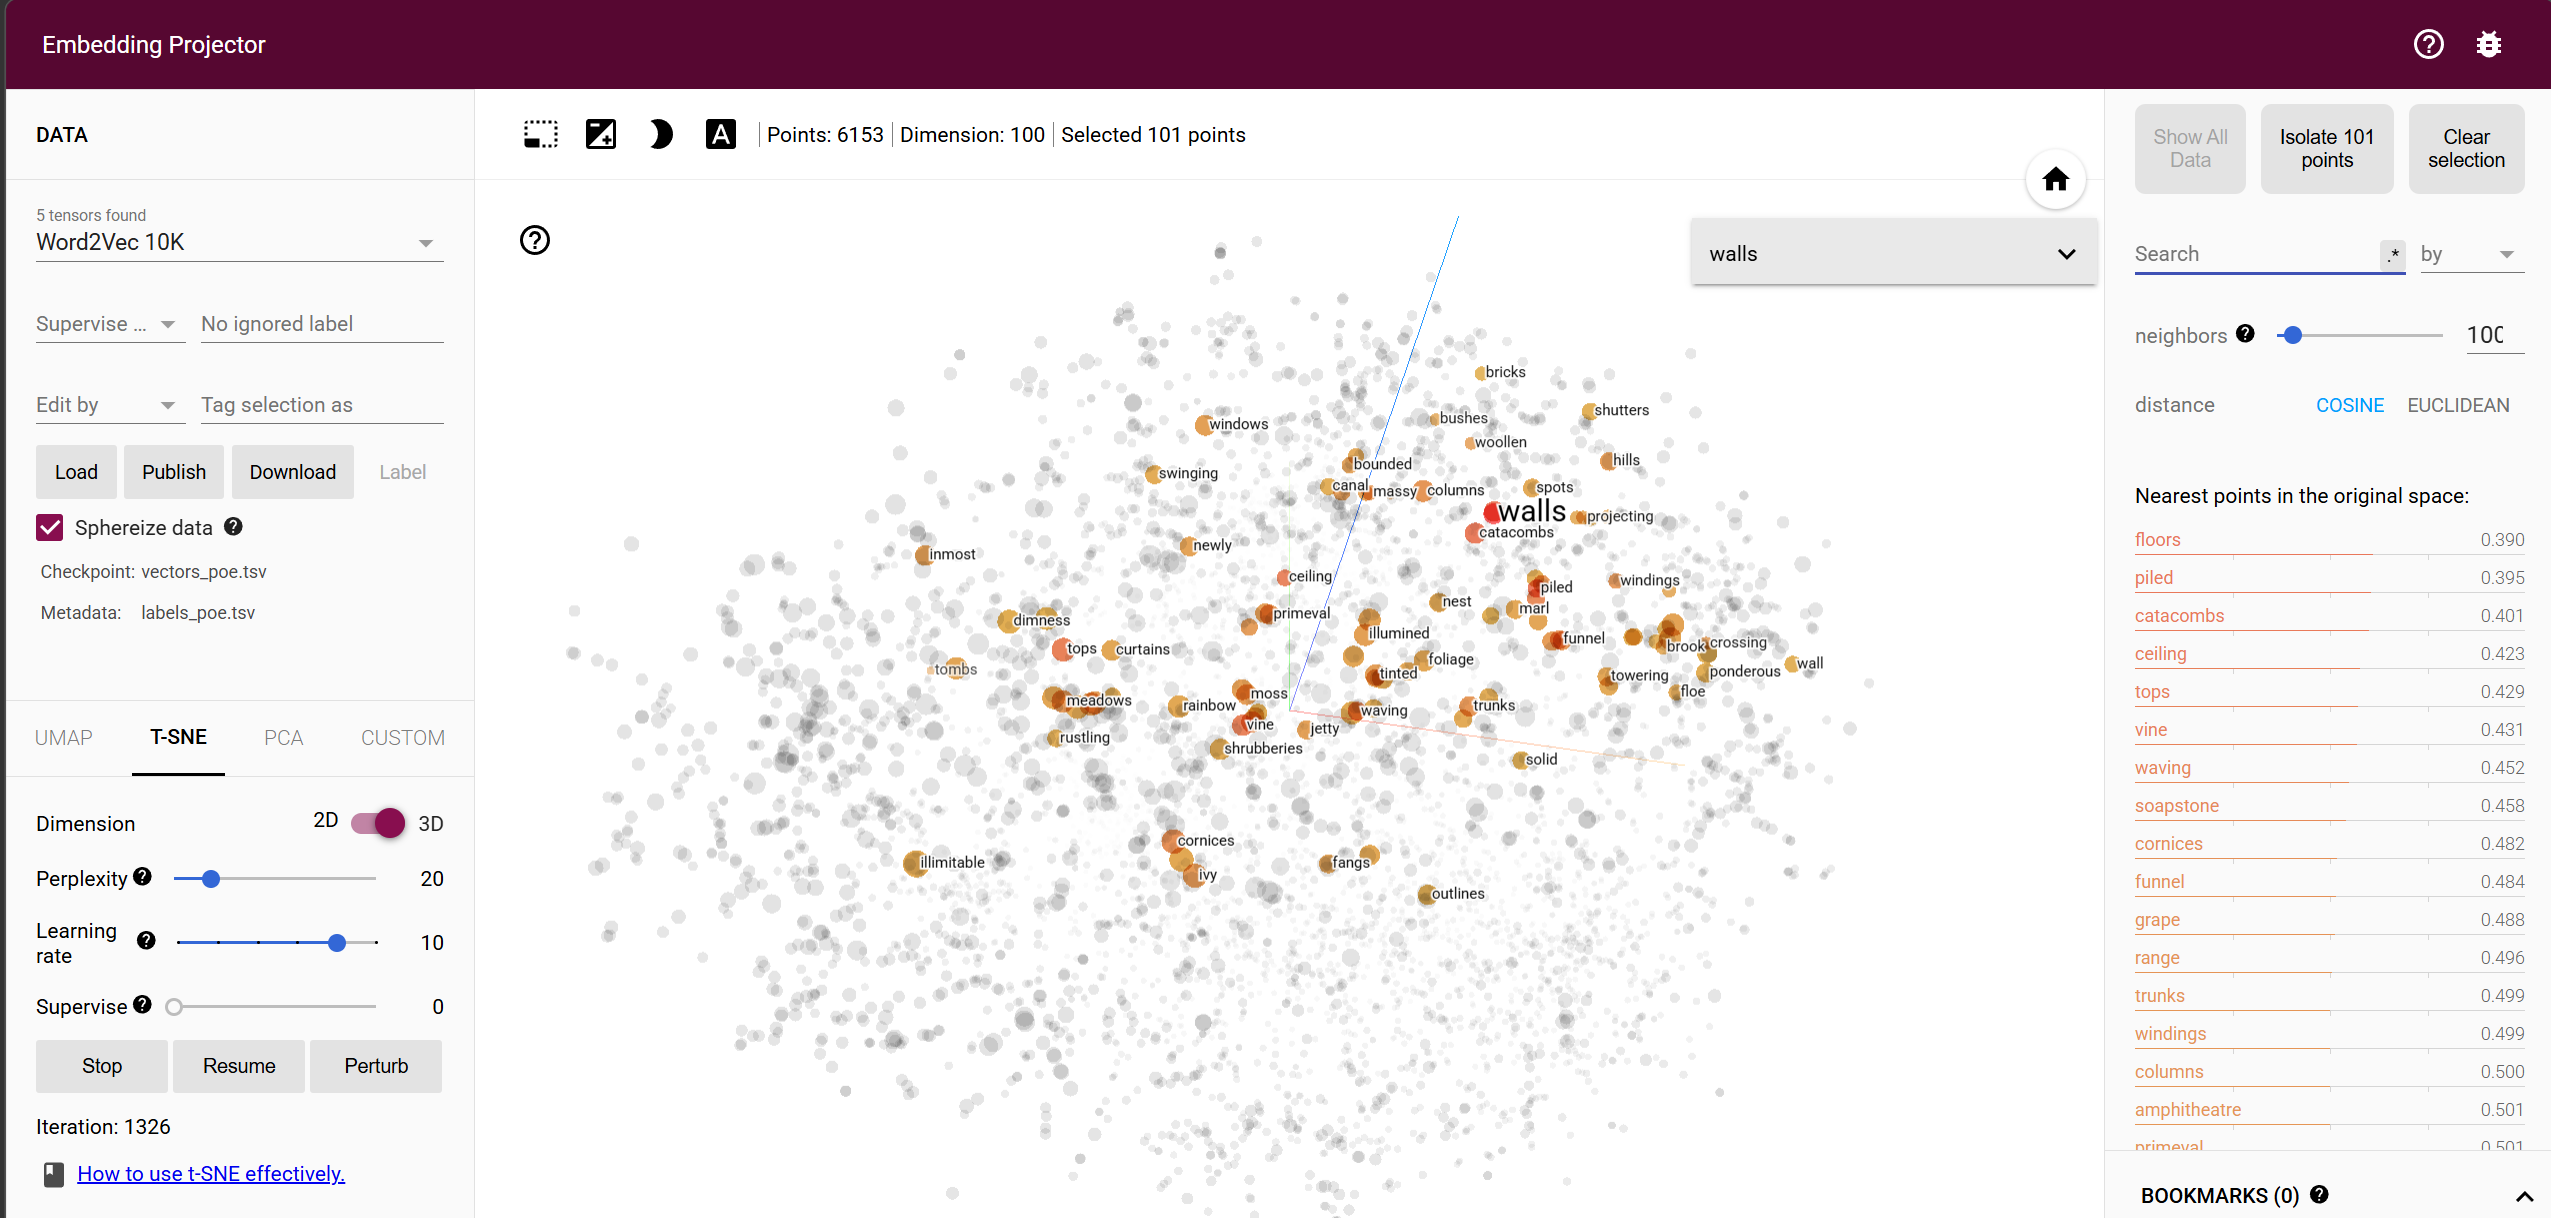

## 9 — Conclusiones

1. **Calidad de los embeddings**: Con **9,415 oraciones** y **4,878 palabras en vocabulario** tras la limpieza editorial mejorada, el modelo captura relaciones semánticas muy específicas de la obra de Poe. Las similitudes más altas llegan a **0.82** (`raven`↔`quoth`), y el rango típico de las similitudes semánticas va de **0.55 a 0.67**, valores altos para un corpus de tamaño modesto (~9k oraciones).

2. **Hallazgo más sólido: la fusión `love` ↔ `beloved` (0.64) y el triángulo `soul` = `heart` = `psyche`**: la palabra `beloved` es ahora el vecino más cercano de `love`, confirmando el registro amoroso nupcial. Pero el hallazgo más interesante es el **triángulo semántico** `soul`↔`heart`↔`psyche` (similitudes mutuas ~0.58-0.60): las tres palabras son casi intercambiables en el espacio vectorial. `psyche`, en particular, emerge como ancla semántica del corpus poeano, no como contaminante editorial. La analogía `soul + death − body → psyche, heart` lo confirma aritméticamente.

3. **La locura como vía de escape**: el vecino de mayor peso de `madness` tras la limpieza ya no es `pulsation` (que fue filtrada por `min_count=5`) sino `wearied` y, sobre todo, **`freedom` (0.66)**. Esta asociación `madness`↔`freedom` es un hallazgo nuevo que no aparecía en la corrida anterior, y cuantifica una lectura crítica clásica: en Poe la demencia no es solo sufrimiento clínico sino también **liberación** frente a un mundo intolerable.

4. **La noche gótica recuperada**: en la corrida anterior, `night` aparecía definida por contraste con el día (`morning`, `day`, `eve`). Tras la limpieza editorial, `night` recupera su **vecindad onírica genuina**: sus vecinos más cercanos son ahora `dream`, `lovers`, `moon`, `fancy`, `veiling`. Es la noche gótica tal como la esperamos en Poe. La analogía `night + dream − day → moon, twas, behold, wind, veiling` lo confirma con un registro poético impecable.

5. **Confirmaciones del imaginario poeano**:
   - **Confirmado plenamente**: `raven` ↔ `quoth`/`nevermore` (0.82). Desaparecieron los artefactos editoriales (`preface`, `ed`, `1829`, `1839`) que aparecían en la corrida anterior. La limpieza editorial funcionó.
   - **Confirmado por analogía**: la ecuación `raven + bird − silence → quoth, nevermore, query, bust, pallas` es la firma estilística de *The Raven* hecha aritmética vectorial — el cuervo que habla frente al busto de Palas respondiendo a la pregunta del narrador.
   - **Matizado**: el miedo (`fear`) recupera su vecindad con el horror físico (`pale`, `startled`, `terror`, `grief`) pero conserva un matiz social (`ashamed`) que matiza la lectura puramente gótica.

6. **Limpieza editorial: resultados y caveat**: la heurística `strip_editorial_matter` eliminó prefacios, introducciones, biografías, apéndices, notas e índices del editor, y los artefactos editoriales (`preface`, `ed`, años) dejaron de aparecer como vecinos. **Caveat importante**: en la corrida actual, `Poe_Works_Vol3.txt` quedó con **0 oraciones (editorial: -100.0%)**: la función sobre-limpió ese volumen. La causa más probable es que el primer header de contenido de Vol 3 no satisface el predicado `4 <= len(stripped) < 80 and stripped == upper`, por lo que `skip_section` nunca termina y se descarta todo el archivo hasta "Produced by". Se añadió un **safety-net del 20%** a la función para evitar este caso: si se descartara más del 20% del texto, se reactiva la inclusión. Una corrida futura con esta corrección debería restaurar las oraciones de Vol 3.

7. **Pérdida ruidosa, convergencia no monótona**: la curva de pérdida muestra oscilaciones marcadas (epoch 1 = 816,669; epoch 7 = 603,120; epoch 20 = 387,348). El pico inicial tan alto sugiere que el learning rate por defecto podría ser agresivo para este corpus; un `alpha` decay explícito o un `min_alpha` mayor probablemente suavizarían la curva. No es un problema para la calidad de los embeddings (los vecinos son coherentes) pero sí una indicación de que el entrenamiento es subóptimo.

8. **Limitaciones**:
   - **Vol 3 perdido**: 0 oraciones, ~30% del corpus potencial. Una re-corrida con la versión safety-net de `strip_editorial_matter` debería restaurar Vol 3.
   - **Corpus aún pequeño**: 9,415 oraciones es un tamaño modesto. Las relaciones semánticas son robustas pero el modelo no generaliza más allá del léxico que vio: analogías como `madness + pulsation − mind` fallan porque `pulsation` fue filtrada.
   - **`min_count=5` filtra arcaísmos**: `thee`, `thou`, `couldst`, `pulsation` se pierden. Una variante con `min_count=3` recuperaría parte de este registro poético del siglo XIX a costa de más ruido.
   - **Stopwords no removidas**: dominan parcialmente el espacio. Una versión con stopwords removidas produciría clusters más limpios, pero se perderían relaciones sintácticas que ahora capturan polisemia.
